# 01 wage education analysis

In [2]:
!pip install pygam

import numpy as np
import pandas as pd
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, te

pd.set_option('display.max_columns', None)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pygam]


## After got data from the website, I prepared and cleaned this data

In [5]:
acs_data = pd.read_csv('/Users/sophialiu/Downloads/machine_learning/mini-project-1/data/usa_00001.csv')
acs_data.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,NCHILD,SEX,AGE,MARST,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,VETSTAT,VETSTATD
0,2023,202301,1360,2023010064639,7290.0,2023000013601,210101,4,1,7290.0,0,2,19,6,1,100,0,0,7,71,1,12,25000,1,11
1,2023,202301,2170,2023010105958,6156.0,2023000021701,140301,4,1,6156.0,0,1,21,6,2,200,0,0,7,71,1,10,18000,1,11
2,2023,202301,3790,2023000007437,4050.0,2023000037901,230001,1,2,3402.0,0,2,60,1,8,802,0,0,6,63,1,10,28000,1,11
3,2023,202301,3952,2023000019066,10206.0,2023000039521,150101,1,1,10206.0,0,2,70,2,1,100,0,0,6,64,1,10,100000,1,11
4,2023,202301,4762,2023000074067,12798.0,2023000047621,190101,1,1,12798.0,0,2,64,1,1,100,0,0,8,81,1,10,88000,1,11


### (a) Using a Crosswalk dataframe - Converting EDUCD to continuous

**Crosswalk**: refers to a type of data mapping used to align or translate one set of data values to another.

In [ ]:
acs_data['EDUCD'].unique

<bound method Series.unique of 0       71
1       71
2       63
3       64
4       81
        ..
9458    63
9459    65
9460    65
9461    65
9462    71
Name: EDUCD, Length: 9463, dtype: int64>

In [8]:
crosswalk = pd.read_csv('/Users/sophialiu/Downloads/machine_learning/mini-project-1/data/Education-Crosswalk.csv')
crosswalk.head()

,educd,educdc
0,2,0.0
1,10,0.0
2,11,2.0
3,12,0.0
4,13,2.5


In [ ]:
crosswalk['educd'].unique()

array([  2,  10,  11,  12,  13,  14,  15,  16,  17,  20,  21,  22,  23,
        24,  25,  26,  30,  40,  50,  61,  62,  63,  64,  65,  70,  71,
        80,  81,  82,  83,  90, 100, 101, 110, 111, 112, 113, 114, 115,
       116])

In [ ]:
# In order to match the 'educd' variable in the crosswalk to the 'EDUCD' variable in the acs data, we need them to have the same name.  
crosswalk = crosswalk.rename(columns={'educd': 'EDUCD', 'educdc': 'EDUCDC'})
crosswalk.head()

,EDUCD,EDUCDC
0,2,0.0
1,10,0.0
2,11,2.0
3,12,0.0
4,13,2.5


In [14]:
# map the matching values of EDUCD between the two dataframes (i.e. merge on EDUCD)
acs_data = acs_data.merge(crosswalk, on='EDUCD', how='left')

In [15]:
# check the data for our changes - the new continuous variable will be found at the end 
acs_data.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,NCHILD,SEX,AGE,MARST,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,VETSTAT,VETSTATD,EDUCDC
0,2023,202301,1360,2023010064639,7290.0,2023000013601,210101,4,1,7290.0,0,2,19,6,1,100,0,0,7,71,1,12,25000,1,11,14.0
1,2023,202301,2170,2023010105958,6156.0,2023000021701,140301,4,1,6156.0,0,1,21,6,2,200,0,0,7,71,1,10,18000,1,11,14.0
2,2023,202301,3790,2023000007437,4050.0,2023000037901,230001,1,2,3402.0,0,2,60,1,8,802,0,0,6,63,1,10,28000,1,11,12.0
3,2023,202301,3952,2023000019066,10206.0,2023000039521,150101,1,1,10206.0,0,2,70,2,1,100,0,0,6,64,1,10,100000,1,11,12.0
4,2023,202301,4762,2023000074067,12798.0,2023000047621,190101,1,1,12798.0,0,2,64,1,1,100,0,0,8,81,1,10,88000,1,11,14.0


### Create dummy variables - Convert VETSTAT, RACE, and MARST to dummy

#### b) Veteran Status - Create a dummy variable, VET, equal to 1 if the individual is a veteran.

In [16]:
acs_data['VETSTAT'].unique()
# 2 means a vet, 1 means not -> you can find this in the documentation online & in codebook [Link]

array([1, 2, 0])

In [18]:
## creating a new dummy variable "VET" in the data
## np.where(condition, value assigned when condition met, value assigned when condition not met)
acs_data['VET'] = np.where(acs_data['VETSTAT'] == 'Yes', 1, 0)


VET == 1 if the individual is a vet.

VET == 0 if the individual is not a vet.

#### c) Race - Create dummy variables, WHITE and BLACK, from the RACE variable

In the original data, RACE == 1 when the individual is White, and RACE == 2 when the individual is Black. Create two new dummy variables WHITE and BLACK using this information.

In [23]:
# creating two new dummy variables "WHITE"and "BLACK" in the data
acs_data['WHITE'] = np.where(acs_data['RACE'] == 1, 1, 0)
acs_data['BLACK'] = np.where(acs_data['RACE'] == 2, 1, 0)

WHITE == 1 if the individual is White, 0 otherwise.

BLACK == 1 if the individual is Black, 0 otherwise.

#### d) Marital Status - Create a dummy variable, MAR, equal to 1 if the person is married.

In [24]:
# Check the unqique values
acs_data['MARST'].unique()
# MARST = 1, 2 implies married.  

array([6, 1, 2, 4, 3, 5])

In [26]:
# creating new dummy variable "MAR" in the data
acs_data['MAR'] = np.where(
    (acs_data['MARST'] == 1) & (acs_data['MARST'] == 2),
    1,
    0
)

MAR == 1 if married.


MAR == 0 if not married.

In [27]:
# check the data for our changes - the 4 new dummy variables will be found at the end 
acs_data.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,NCHILD,SEX,AGE,MARST,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,VETSTAT,VETSTATD,EDUCDC,VET,WHITE,BLACK,MAR
0,2023,202301,1360,2023010064639,7290.0,2023000013601,210101,4,1,7290.0,0,2,19,6,1,100,0,0,7,71,1,12,25000,1,11,14.0,0,1,0,0
1,2023,202301,2170,2023010105958,6156.0,2023000021701,140301,4,1,6156.0,0,1,21,6,2,200,0,0,7,71,1,10,18000,1,11,14.0,0,0,1,0
2,2023,202301,3790,2023000007437,4050.0,2023000037901,230001,1,2,3402.0,0,2,60,1,8,802,0,0,6,63,1,10,28000,1,11,12.0,0,0,0,0
3,2023,202301,3952,2023000019066,10206.0,2023000039521,150101,1,1,10206.0,0,2,70,2,1,100,0,0,6,64,1,10,100000,1,11,12.0,0,1,0,0
4,2023,202301,4762,2023000074067,12798.0,2023000047621,190101,1,1,12798.0,0,2,64,1,1,100,0,0,8,81,1,10,88000,1,11,14.0,0,1,0,0


Note about converting categorical to dummy variables:  
There are several possible approaches to encode categorical values, and statsmodels has built-in support
for many of them. In general these work by splitting a categorical variable into many different binary variables. 
The simplest way to encode categoricals is “dummy-encoding” which encodes a k-level categorical variable into k-1 
binary variables. In statsmodels this is done easily using the C() function.

### Geneating new variables - Create new information from the INCWAGE variable 

#### e) Income - Create a new variable for the natural log of INCWAGE

In [37]:
# We first drop those with 0 income. This is because ln(0) is undefined
# creating new variable "INCWAGE_log" in the data, the natural log of INCWAGE 
import numpy as np
import pandas as pd

acs_data = pd.read_csv("/Users/sophialiu/Downloads/machine_learning/mini-project-1/data/usa_00001.csv")   

acs_data.columns = acs_data.columns.str.strip()          
acs_data.columns = acs_data.columns.str.upper()          

assert 'INCWAGE' in acs_data.columns


acs_data = acs_data.loc[acs_data['INCWAGE'].notna() & (acs_data['INCWAGE'] > 0)].copy()

acs_data['INCWAGE_LOG'] = np.log(acs_data['INCWAGE'])     # 若必须保留0，可用 np.log1p

print(acs_data[['INCWAGE','INCWAGE_LOG']].head(10))


    INCWAGE  INCWAGE_LOG
0     25000    10.126631
1     18000     9.798127
2     28000    10.239960
3    100000    11.512925
4     88000    11.385092
5     76000    11.238489
6     15600     9.655026
8     41100    10.623763
9    130000    11.775290
10    18800     9.841612


#### e) Income - Create a new variable for INCWAGE squared

In [39]:
# creating new variable "INCWAGESQ" in the data, which is the square of INCWAGE
acs_data['INCWAGESQ'] = np.power(acs_data['INCWAGE'], 2)

In [40]:
# check the data for our changes - the 2 new income variables will be found at the end 
acs_data.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,NCHILD,SEX,AGE,MARST,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,VETSTAT,VETSTATD,INCWAGE_LOG,INCWAGESQ
0,2023,202301,1360,2023010064639,7290.0,2023000013601,210101,4,1,7290.0,0,2,19,6,1,100,0,0,7,71,1,12,25000,1,11,10.126631,625000000
1,2023,202301,2170,2023010105958,6156.0,2023000021701,140301,4,1,6156.0,0,1,21,6,2,200,0,0,7,71,1,10,18000,1,11,9.798127,324000000
2,2023,202301,3790,2023000007437,4050.0,2023000037901,230001,1,2,3402.0,0,2,60,1,8,802,0,0,6,63,1,10,28000,1,11,10.239960,784000000
3,2023,202301,3952,2023000019066,10206.0,2023000039521,150101,1,1,10206.0,0,2,70,2,1,100,0,0,6,64,1,10,100000,1,11,11.512925,10000000000
4,2023,202301,4762,2023000074067,12798.0,2023000047621,190101,1,1,12798.0,0,2,64,1,1,100,0,0,8,81,1,10,88000,1,11,11.385092,7744000000


### 4 Data Analysis Questions

#### 1. Compute descriptive (summary) statistics for the following variables: year, incwage, lnincwage,educdc, f emale, age, age2, white, black, hispanic, married, nchild, vet, hsdip, coldip, and the interaction terms.

In [41]:
acs_data.columns

Index(['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STRATA',
       'GQ', 'PERNUM', 'PERWT', 'NCHILD', 'SEX', 'AGE', 'MARST', 'RACE',
       'RACED', 'HISPAN', 'HISPAND', 'EDUC', 'EDUCD', 'EMPSTAT', 'EMPSTATD',
       'INCWAGE', 'VETSTAT', 'VETSTATD', 'INCWAGE_LOG', 'INCWAGESQ'],
      dtype='object')

In [ ]:
acs_data['FEMALE'] = np.where(acs_data['SEX'] == 2, 1, 0)

acs_data['AGE2'] = acs_data['AGE'] ** 2

acs_data['WHITE'] = np.where(acs_data['RACE'] == 1, 1, 0)
acs_data['BLACK'] = np.where(acs_data['RACE'] == 2, 1, 0)

acs_data['HISPANIC'] = np.where(acs_data['HISPAN'] > 0, 1, 0)

acs_data['MARRIED'] = np.where(acs_data['MARST'] == 1, 1, 0)

acs_data['VET'] = np.where(acs_data['VETSTAT'] == 1, 1, 0)

acs_data['HSDIP'] = np.where(acs_data['EDUCD'] == 116, 1, 0)  # 116 = High school diploma

acs_data['COLDIP'] = np.where(acs_data['EDUCD'] == 125, 1, 0)  # 125 = Bachelor's degree

acs_data['FEMALE_WHITE'] = acs_data['FEMALE'] * acs_data['WHITE']
acs_data['AGE_EDUC'] = acs_data['AGE'] * acs_data['EDUCD']
acs_data['MARRIED_BLACK'] = acs_data['MARRIED'] * acs_data['BLACK']

vars_to_summarize = [
    "YEAR", "INCWAGE", "INCWAGE_LOG", "EDUCD", "FEMALE", "AGE", "AGE2",
    "WHITE", "BLACK", "HISPANIC", "MARRIED", "NCHILD", "VET", "HSDIP", "COLDIP",
    "FEMALE_WHITE", "AGE_EDUC", "MARRIED_BLACK"
]

summary_stats = acs_data[vars_to_summarize].describe().T
print(summary_stats)



                count          mean           std          min           25%  \
YEAR           9007.0   2023.000000      0.000000  2023.000000   2023.000000   
INCWAGE        9007.0  68557.269901  81629.943612    30.000000  25000.000000   
INCWAGE_LOG    9007.0     10.624869      1.147712     3.401197     10.126631   
EDUCD          9007.0     81.592761     23.269230     2.000000     63.000000   
FEMALE         9007.0      0.485067      0.499805     0.000000      0.000000   
AGE            9007.0     42.498168     14.391244    16.000000     30.000000   
AGE2           9007.0   2013.179194   1241.521713   256.000000    900.000000   
WHITE          9007.0      0.657600      0.474539     0.000000      0.000000   
BLACK          9007.0      0.080826      0.272583     0.000000      0.000000   
HISPANIC       9007.0      0.163762      0.370080     0.000000      0.000000   
MARRIED        9007.0      0.520262      0.499617     0.000000      0.000000   
NCHILD         9007.0      0.737648     

In [45]:
mean_age = acs_data['AGE'].mean()
std_age = acs_data['AGE'].std()

print("Mean age:", mean_age)
print("Standard Deviation:", std_age)

Mean age: 42.4981680914844
Standard Deviation: 14.391243759051418


#### 2. Scatter plot ln(incwage) and education (the continuous measure). Include a linear fit line. Be sure to label all axes and include an informative title.

*Remember to use `fig, ax = plt.subplots()` to make your plots, as you learned in Python I and II*

In [46]:
import matplotlib.pyplot as plt

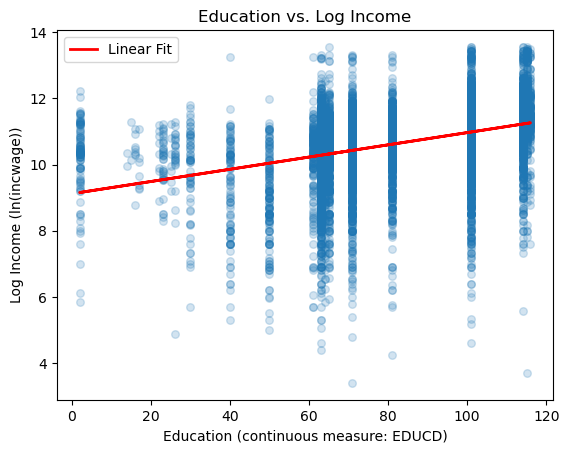

In [ ]:
fig, ax = plt.subplots()

# Scatterplot of age vs. income using the ax object
ax.scatter(acs_data['EDUCD'], acs_data['INCWAGE_LOG'], alpha=0.2, s=30)
# Note: alpha controls the transparency (0=transparent, 1=opaque)
#       s controls the size of the scatter plot markers
# linear fit line
m, b = np.polyfit(acs_data['EDUCD'], acs_data['INCWAGE_LOG'], 1)
ax.plot(acs_data['EDUCD'], m*acs_data['EDUCD'] + b, color='red', linewidth=2, label='Linear Fit')
# Setting the title, and labels using the ax object
ax.set_title('Education vs. Log Income')
ax.set_xlabel('Education (continuous measure: EDUCD)')
ax.set_ylabel('Log Income (ln(incwage))')
ax.legend()
plt.show()

### 3. Estimate model:

In [63]:
import statsmodels.formula.api as smf
result = smf.ols(
    formula="INCWAGE_LOG ~ EDUCD + SEX + AGE + I(AGE**2) + RACE + MARST + NCHILD + VETSTAT", 
    data=acs_data
).fit()

print(result.summary())
adj_r2_q3 = result.rsquared_adj
print("Adjusted R² (Q3 quadratic model):", adj_r2_q3)

                            OLS Regression Results                            
Dep. Variable:            INCWAGE_LOG   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     556.8
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:28:14   Log-Likelihood:                -12210.
No. Observations:                9007   AIC:                         2.444e+04
Df Residuals:                    8998   BIC:                         2.450e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.6513      0.118     56.161      

### 4. Graph ln(incwage) and education. Include three distinct linear fit lines specific to individuals with no high school diploma, a high school diploma, and a college degree. Be sure to label all axes and include an informative title.

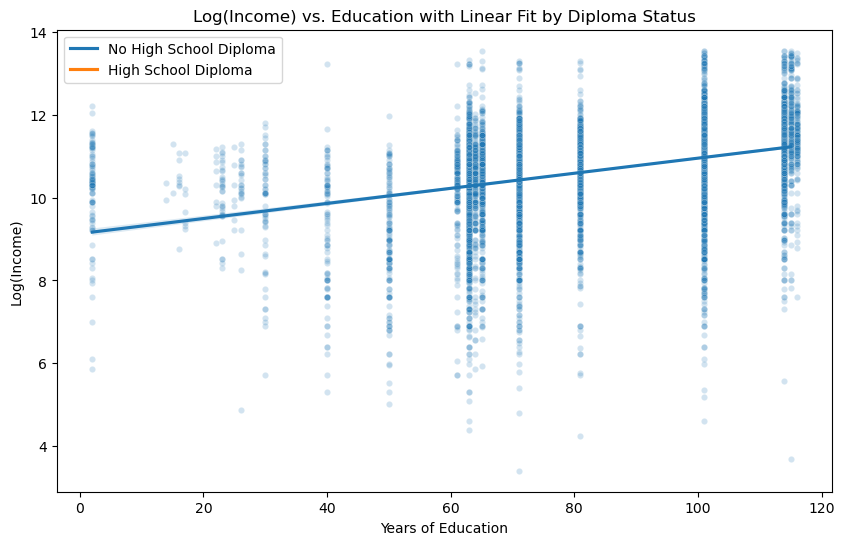

In [55]:
no_hs = acs_data[acs_data['HSDIP'] == 0]
hs = acs_data[acs_data['HSDIP'] == 1]
college = acs_data[acs_data['COLDIP'] == 1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='EDUCD', y='INCWAGE_LOG', data=acs_data, alpha=0.2, s=20)

sns.regplot(x='EDUCD', y='INCWAGE_LOG', data=no_hs, 
            scatter=False, label="No High School Diploma")

sns.regplot(x='EDUCD', y='INCWAGE_LOG', data=hs, 
            scatter=False, label="High School Diploma")

sns.regplot(x='EDUCD', y='INCWAGE_LOG', data=college, 
            scatter=False, label="College Degree")

plt.title("Log(Income) vs. Education with Linear Fit by Diploma Status")
plt.xlabel("Years of Education")
plt.ylabel("Log(Income)")
plt.legend()
plt.show()


### 5. determine a tool that can be used to predict wages for those considering a college degree so that future constituents can make informed decisions.

**(a) Differential intercept/slope model**

We specify the following model:

$$
\ln(\text{incwage}_i) = \beta_0 + \beta_1 \text{educ}_i
+ \beta_2 (\text{educ}_i \times HS_i)
+ \beta_3 (\text{educ}_i \times COL_i)
+ \beta_4 female_i + \beta_5 age_i + \beta_6 age_i^2
+ \beta_7 white_i + \beta_8 black_i + \beta_9 hispanic_i
+ \beta_{10} married_i + \beta_{11} nchild_i + \beta_{12} vet_i + \varepsilon_i
$$

where:  
- \(HS_i = 1\) if high school diploma, 0 otherwise  
- \(COL_i = 1\) if college degree, 0 otherwise  
- baseline group: no high school diploma

This specification allows the return to education (the slope of `educ`) to vary by degree attained (no HS, HS, or College).  
Intuitively, the return to each additional year of schooling might differ depending on whether the individual crosses the threshold of completing HS or college. This reflects credential effects in the labor market.  
We also keep controls (age, age², gender, race, marital status, children, veteran status) to avoid omitted variable bias.  
This balances flexibility (not forcing the same slope for all) with parsimony (not overfitting).


#### （b）Estimate model

In [56]:
import statsmodels.formula.api as smf

# Create dummy variables for HS and COL degrees (baseline = no HS diploma)
acs_data['HS'] = (acs_data['EDUCD'] == 62).astype(int)  # example: code for HS diploma
acs_data['COL'] = (acs_data['EDUCD'] >= 101).astype(int)  # example: college degree or higher

# Fit the differential slope model
model = smf.ols(
    formula="INCWAGE_LOG ~ EDUCD + EDUCD:HS + EDUCD:COL + SEX + AGE + I(AGE**2) + WHITE + BLACK + HISPAN + MARST + NCHILD + VETSTAT",
    data=acs_data
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            INCWAGE_LOG   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     412.0
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:13:40   Log-Likelihood:                -12183.
No. Observations:                9007   AIC:                         2.439e+04
Df Residuals:                    8995   BIC:                         2.448e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.8220      0.128     53.387      

#### （c）prediction
 We predict the wages of:
- A 22-year-old female (not white, not black, not hispanic, not married, no children, not a veteran), 
  with a HS diploma vs. with a college degree.  

Interpretation:
- Plugging values: for HS, EDUCD=12, HS=1, COL=0.  
- For College, EDUCD=16, HS=0, COL=1.  
The difference in predicted log wages between HS and COL reflects the college wage premium.


In [57]:
# Predict wages for HS vs COL at age 22, female, others = 0
new_data = pd.DataFrame({
    'EDUCD': [12, 16],
    'HS': [1, 0],
    'COL': [0, 1],
    'SEX': [1, 1],  # 1 = female
    'AGE': [22, 22],
    'WHITE': [0, 0],
    'BLACK': [0, 0],
    'HISPAN': [0, 0],
    'MARST': [0, 0],
    'NCHILD': [0, 0],
    'VETSTAT': [0, 0]
})

predictions = model.get_prediction(new_data).summary_frame(alpha=0.05)
print(predictions[['mean', 'mean_ci_lower', 'mean_ci_upper']])



       mean  mean_ci_lower  mean_ci_upper
0  9.245628       9.095304       9.395952
1  9.317539       9.165514       9.469565


## 6. Splines

### (a) Cubic spline with knots at 24 and 55
We estimate a cubic spline in AGE with two knots at 24 and 55, while keeping other predictors 
from Question 3 in the model. We then report the adjusted R².


In [58]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# predictors and outcome
X_age = acs_data[["AGE"]].values
y = acs_data["INCWAGE"].values

# knots at 24 and 55
spline_transformer = SplineTransformer(degree=3, knots=[[24],[55]])
X_splines = spline_transformer.fit_transform(X_age)

# add controls from Q3
controls = acs_data[["FEMALE","WHITE","BLACK","HISPANIC","MARRIED","NCHILD","VET","EDUC"]].values
X = np.hstack([X_splines, controls])

# fit model
model = LinearRegression()
model.fit(X, y)

# adjusted R²
r2 = model.score(X,y)
n, p = X.shape
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("Adjusted R² (Spline, knots 24 & 55):", adj_r2)


Adjusted R² (Spline, knots 24 & 55): 0.19117733484607835


### (b) Comparison with Question 3 regression
We compare the adjusted R² from the spline model above with the adjusted R² from the quadratic 
age regression in Question 3. The difference arises because splines allow local flexibility, 
while the quadratic imposes a global functional form.


In [64]:

print("Adjusted R² (Q3 quadratic model):", adj_r2_q3) 
print("Adjusted R² (Spline, knots 24 & 55):", adj_r2)


Adjusted R² (Q3 quadratic model): 0.33053076545919546
Adjusted R² (Spline, knots 24 & 55): 0.19117733484607835


### (c) Alternative spline specifications
We try three spline models:
1. Cubic spline with knots at 18 and 65  
2. Natural cubic spline with knots at 18 and 65  
3. A cubic spline with knots at 30 and 50  

We compare their adjusted R² values and discuss which fits best.


In [65]:
# 1. cubic spline knots at 18,65
spline1 = SplineTransformer(degree=3, knots=[[18],[65]])
X1 = np.hstack([spline1.fit_transform(X_age), controls])
m1 = LinearRegression().fit(X1,y)
r2_1 = m1.score(X1,y)
adj_r2_1 = 1 - (1-r2_1)*(n-1)/(n-X1.shape[1]-1)

# 2. natural cubic spline knots at 18,65 (set extrapolation="linear")
spline2 = SplineTransformer(degree=3, knots=[[18],[65]], extrapolation="linear")
X2 = np.hstack([spline2.fit_transform(X_age), controls])
m2 = LinearRegression().fit(X2,y)
r2_2 = m2.score(X2,y)
adj_r2_2 = 1 - (1-r2_2)*(n-1)/(n-X2.shape[1]-1)

# 3. cubic spline knots at 30,50
spline3 = SplineTransformer(degree=3, knots=[[30],[50]])
X3 = np.hstack([spline3.fit_transform(X_age), controls])
m3 = LinearRegression().fit(X3,y)
r2_3 = m3.score(X3,y)
adj_r2_3 = 1 - (1-r2_3)*(n-1)/(n-X3.shape[1]-1)


print("Adjusted R² (cubic knots 18,65):", adj_r2_1)
print("Adjusted R² (natural cubic knots 18,65):", adj_r2_2)
print("Adjusted R² (cubic knots 30,50):", adj_r2_3)


Adjusted R² (cubic knots 18,65): 0.1926524869090841
Adjusted R² (natural cubic knots 18,65): 0.1935979933220051
Adjusted R² (cubic knots 30,50): 0.18977933355881949


### (d) Predictions at ages 17 and 50
Using the cubic spline with knots at 18 and 65 (from part c1), we predict wages for 
a female individual (12 years of education, not white, black, or Hispanic, unmarried, 
no children, not a veteran) at ages 17 and 50. The two predictions differ because the 
spline allows for nonlinear age effects: slope changes before/after knots imply different 
returns to age at early vs. later life.


In [66]:
# test individuals at age 17 and 50
test = pd.DataFrame({
    "AGE":[17,50],
    "EDUC":[12,12],
    "FEMALE":[1,1],
    "WHITE":[0,0],
    "BLACK":[0,0],
    "HISPANIC":[0,0],
    "MARRIED":[0,0],
    "NCHILD":[0,0],
    "VET":[0,0]
})

# spline features
test_spline = spline1.transform(test[["AGE"]])   # spline1 is cubic with knots at 18,65
X_test = np.hstack([test_spline, test.drop(columns=["AGE"]).values])

pred = m1.predict(X_test)
print("Predicted income at age 17:", pred[0])
print("Predicted income at age 50:", pred[1])


Predicted income at age 17: -361907.98017840507
Predicted income at age 50: -318322.4277142231


/opt/miniconda3/envs/DAP/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SplineTransformer was fitted without feature names
  warnings.warn(


### Visualization

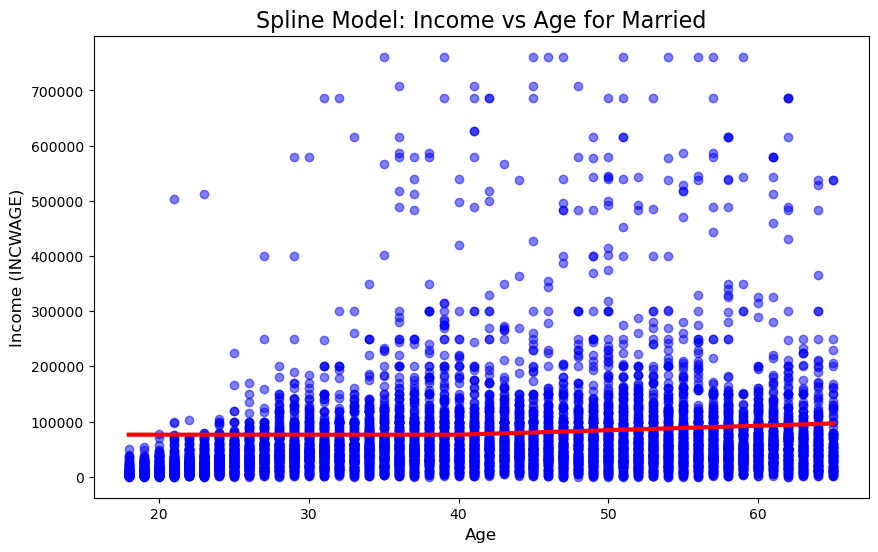

In [ ]:
age_grid = pd.DataFrame({
    "AGE": np.linspace(acs_data["AGE"].min(), acs_data["AGE"].max(), 100),
    "MAR": 1  #for this visualization we're plotting all ages conditional on being married, so we generate a sequence of all ages.

})

age_grid_splines = spline_transformer.transform()
X_grid = np.hstack([age_grid_splines,])
age_grid["predicted"] = model.predict(age_grid_splines) # predict takes a vector predictors similar to regular regression, AGE, MAR ect.

plt.figure(figsize=(10, 6))
plt.scatter(acs_data["AGE"], acs_data["INCWAGE"], alpha=0, color="blue", label="Data")
plt.plot(age_grid["AGE"], age_grid["predicted"], color="red", linewidth=3, label="Spline Fit (MAR=1)")
plt.title("Spline Model: Income vs Age for Married", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income (INCWAGE)", fontsize=12)
plt.show()


## Generalized Additive Models (GAMs)

Generalized Additive Models are an extension of linear regression which allow for non-linear relationships by allowing each predictor to have it's own curve (often similar to splines) while retaining the interperatability we know and love from linear regression.

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     40.3547
Link Function:                     IdentityLink Log Likelihood:                               -199610.1677
Number of Samples:                         8571 AIC:                                           399303.0448
                                                AICc:                                          399303.4555
                                                GCV:                                       5234756928.8668
                                                Scale:                                     5190411467.9851
                                                Pseudo R-Squared:                                   0.2037
Feature Function                  Lam

C:\Users\15083\AppData\Local\Temp\ipykernel_8304\1462403220.py:12: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_model.summary())


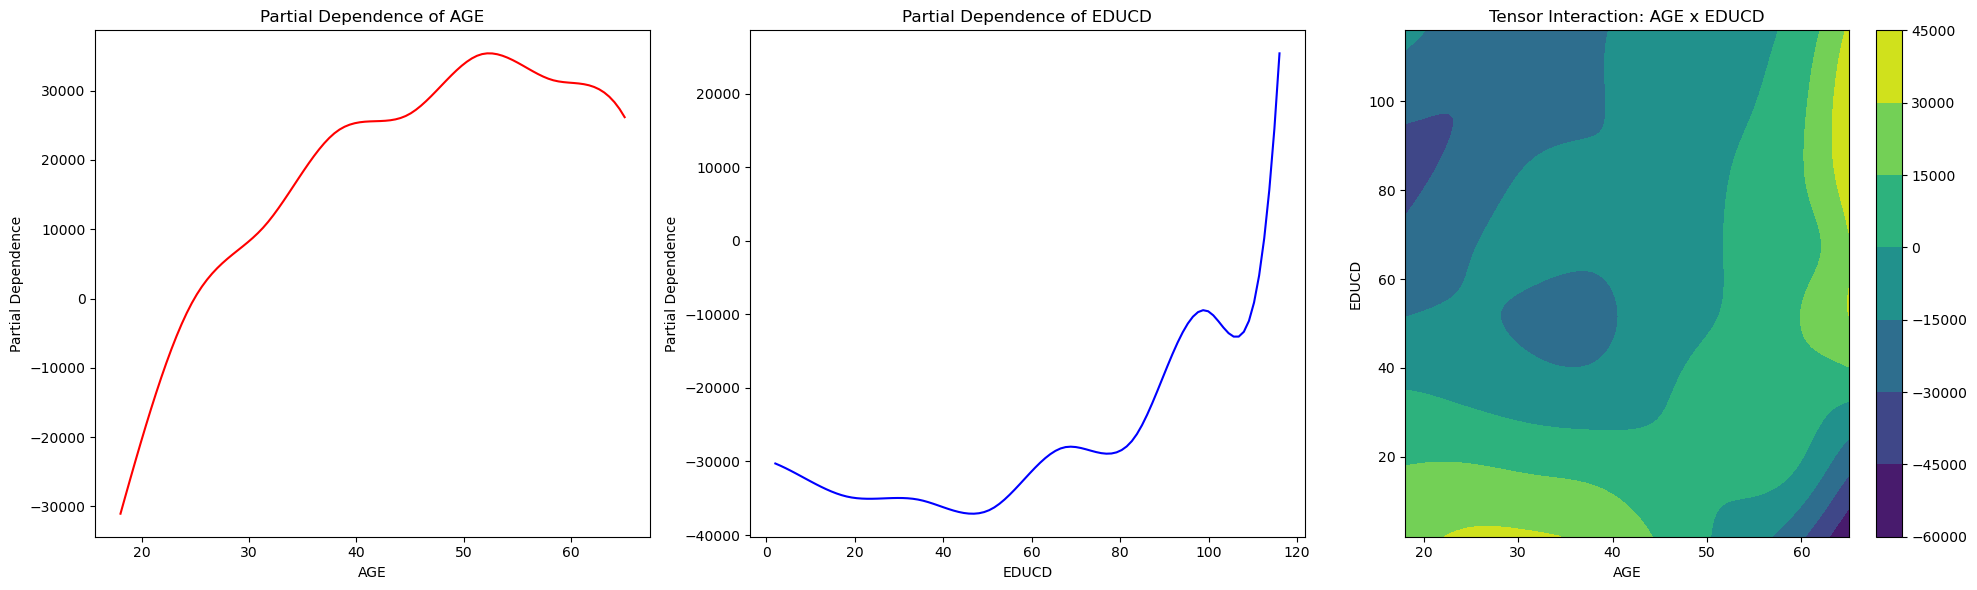

In [ ]:
X = acs_data[["AGE", "EDUCD", "MAR"]].values  # Include AGE, EDUCD, and MAR
y = acs_data["INCWAGE"].values

# Fit GAM model
gam_model = LinearGAM(
    s(0, n_splines=10, spline_order=3) + # Cubic spline for AGE
    s() +  # Cubic spline for  EDUCD
    te() +  #interaction between AGE and EDUCD (look up tensor interaction if interested)
    s()  # MAR as piecewise constant i.e. degree 0
).fit(X, y)

print(gam_model.summary())

#plotting these are slightly complicated in python 
age_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
educd_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
constant_mar = 1  

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# smooth term for AGE
X_partial_age = np.zeros((len(age_grid), X.shape[1]))
X_partial_age[:, 0] = age_grid
X_partial_age[:, 2] = constant_mar
partial_dep_age = gam_model.partial_dependence(term=0, X=X_partial_age)
axs[0].plot(age_grid, partial_dep_age, color="red", label="AGE")
axs[0].set_title("Partial Dependence of AGE")
axs[0].set_xlabel("AGE")
axs[0].set_ylabel("Partial Dependence")

# smooth term for EDUCD
X_partial_educd = np.zeros((len(educd_grid), X.shape[1]))
X_partial_educd[:, 1] = educd_grid
X_partial_educd[:, 2] = constant_mar
partial_dep_educd = gam_model.partial_dependence(term=1, X=X_partial_educd)
axs[1].plot(educd_grid, partial_dep_educd, color="blue", label="EDUCD")
axs[1].set_title("Partial Dependence of EDUCD")
axs[1].set_xlabel("EDUCD")
axs[1].set_ylabel("Partial Dependence")

# tensor interaction (AGE x EDUCD)
X_tensor = np.array([[a, e, constant_mar] for a in age_grid for e in educd_grid])
partial_dep_tensor = gam_model.partial_dependence(term=2, X=X_tensor).reshape(len(age_grid), len(educd_grid))
contour = axs[2].contourf(age_grid, educd_grid, partial_dep_tensor, cmap="viridis")
fig.colorbar(contour, ax=axs[2])
axs[2].set_title("Tensor Interaction: AGE x EDUCD")
axs[2].set_xlabel("AGE")
axs[2].set_ylabel("EDUCD")

plt.tight_layout()
plt.show()